# PCA for Beginners — Understanding Principal Component Analysis

## A complete, code-first walkthrough using a real dataset (Wine)

### What you will understand by the end

1. What problem does PCA solve?
2. What is a Principal Component?
3. Why is a principal component a **weighted combination of features**?
4. Where do those weights actually come from?
5. What is a covariance matrix?
6. Why do eigenvectors and eigenvalues appear in PCA?
7. What does an eigenvector mean in PCA? What does an eigenvalue mean?
8. Why do we usually standardize before PCA?
9. What do `fit`, `transform`, and `fit_transform` do?
10. How do we choose the number of components — and how do we read a "% variance explained" chart?
11. What does PCA actually look like on real, messy data?

> **Note:** We will not use t-SNE or UMAP. They are not needed to understand PCA, and mixing them in only adds confusion for a first pass.

## 0. The Problem Statement

We'll use the **Wine dataset** (built into scikit-learn, no download needed): a chemical analysis of **178 wine
samples**, grown in the same region of Italy but from **3 different cultivars** (grape varieties). For every
wine, **13 chemical measurements** were recorded — alcohol, malic acid, magnesium, color intensity, proline, and so on.

**The problem:**

- 13 features are impossible to plot together — we can only really *see* 2, maybe 3, dimensions at once.
- Many of these chemical measurements move together (wines rich in flavonoids also tend to be rich in total
  phenols, for example) — so a lot of that "13-dimensional-ness" is redundant.
- We would like a small number of *new* features that still capture most of what makes one wine sample
  different from another — few enough that we can actually plot and reason about them.

**This is exactly the problem PCA solves:** take many correlated features and re-express the data using a
smaller number of *uncorrelated* "principal components", while throwing away as little information
(variance) as possible.

We will first build PCA from first principles on a **tiny 2-feature toy example** (so the geometry is easy to
see by eye), and then apply the exact same steps to the **real 13-feature Wine data**.

## 1. Start with the problem — why do we need PCA?

Imagine we only track two things about a group of students:

- Hours studied
- Exam score

Students who study more generally score higher, so the two features move together.

If the points lie almost along one direction, do we really need **two** numbers to describe each student —
or would **one** new number (roughly "how far along that direction") tell us almost as much?

That is the basic intuition behind PCA:

> **Can we replace many original features with a smaller number of new features that preserve most of the
> important variation in the data?**

PCA is a **dimensionality-reduction** technique. Let's see it on this tiny example first.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_wine

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

# A tiny, easy-to-see-by-eye dataset: hours studied vs. exam score.
study_data = pd.DataFrame({
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7],
    "Exam_Score":    [22, 28, 41, 48, 63, 68, 82],
})

study_data

,Hours_Studied,Exam_Score
0,1,22
1,2,28
2,3,41
3,4,48
4,5,63
5,6,68
6,7,82


This time the scores are not a *perfectly* straight line (real data never is) — there's a little bit of
natural noise, which is exactly what we want so the example feels realistic rather than "too perfect."

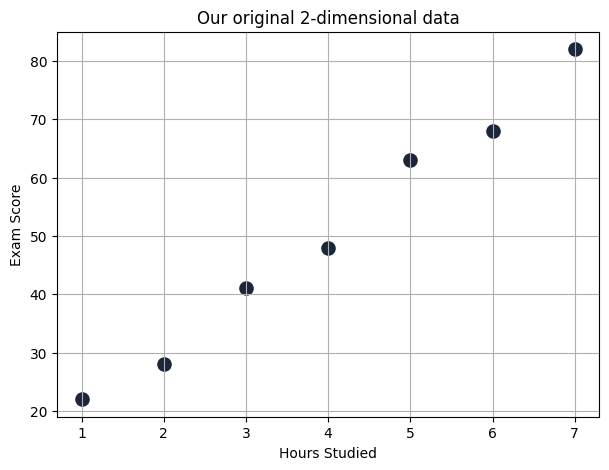

In [ ]:
plt.scatter(study_data["Hours_Studied"], study_data["Exam_Score"], s=90, color="#1B263B")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Our original 2-dimensional data")

plt.show()

## Look at the picture

The data is strongly concentrated around one direction, even with a bit of noise.

PCA asks:

> **What is the best direction through this cloud of points?**

If we can describe most of the variation using that single direction, we can replace the original two
features with **one principal component**.

## 2. What is a Principal Component?

A principal component is a **new axis**, built from the original features.

For two features:

$$
PC1 = w_1X_1 + w_2X_2
$$

For many features (like our 13 wine measurements later):

$$
PC1 = w_1X_1 + w_2X_2 + \dots + w_nX_n
$$

The important question is:

> **Where do these weights $w_1, w_2, \dots$ come from?**

They are **not guessed, and not chosen by us**. PCA calculates them directly from the data — that's the
whole point of the next few sections.

## 3. Before the mathematics: what should PC1 accomplish?

Imagine drawing many possible directions (lines) through our data cloud. For each candidate direction, we
can *project* every point onto that line.

A **good** direction is one where the projected points stay spread out — i.e. it preserves as much of the
data's variation as possible. A **bad** direction squashes everything close together, throwing information away.

So PCA's central idea is:

> **Find the direction along which the data has maximum variance.**

The direction with the most variance becomes **PC1**. Then PCA finds the *next* best direction, subject to
being perpendicular (uncorrelated) to PC1 — that becomes **PC2**, and so on.

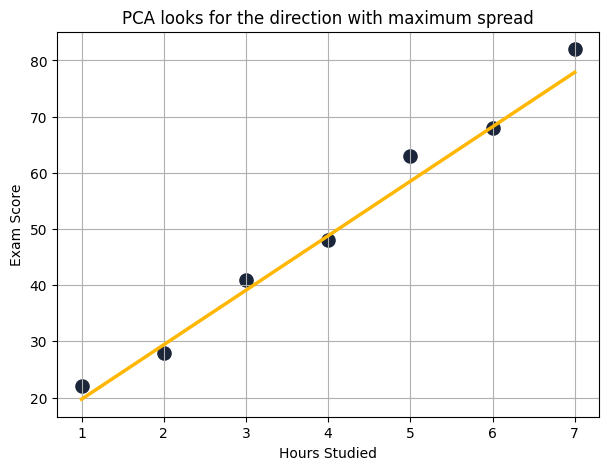

In [ ]:
# Visualize one candidate direction through the data (just for intuition — not yet computed by PCA).
x = study_data["Hours_Studied"].to_numpy()
y = study_data["Exam_Score"].to_numpy()

plt.scatter(x, y, s=90, color="#1B263B")

# A line that roughly follows the main direction of the data.
line_x = np.array([1, 7])
line_y = 9.7 * line_x + 10

plt.plot(line_x, line_y, linewidth=2.5, color="#FFB703")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("PCA looks for the direction with maximum spread")

plt.show()

## 4. Why do we talk about covariance?

Before PCA can find the *best* direction, it needs to understand how the features vary — together.

For our two features, there are three useful questions:

- How much does **Hours Studied** vary on its own?
- How much does **Exam Score** vary on its own?
- Do Hours Studied and Exam Score move **together**?

**Covariance** answers the third question. A **covariance matrix** puts all three answers into one table.

## How to read a 2 × 2 covariance matrix

$$
\begin{bmatrix}
Var(X_1) & Cov(X_1,X_2) \\
Cov(X_1,X_2) & Var(X_2)
\end{bmatrix}
$$

- **Top-left:** variance of feature 1
- **Bottom-right:** variance of feature 2
- **Off-diagonal:** covariance between the two features (positive here → the features increase together)

PCA now knows the *shape* of the data — but we still need to answer:

> **Which direction captures the most variance?**

## 5. Where do eigenvectors come into PCA?

This is the key connection.

PCA wants a direction $w$ such that the data has **maximum variance when projected onto $w$**. When you write
that as a mathematical optimization problem and solve it, you land on:

$$
Cw = \lambda w
$$

where:

- $C$ = the covariance matrix
- $w$ = a direction (a vector)
- $\lambda$ = a number telling us how much variance lies along that direction

That equation is exactly the **eigenvector / eigenvalue** equation. So:

- **Eigenvector → direction.** It tells PCA *which way to point*.
- **Eigenvalue → amount of variance.** It tells PCA *how important* that direction is.

$$
\boxed{\text{Largest eigenvalue} \rightarrow \text{its eigenvector} \rightarrow PC1}
$$

That is the entire reason eigenvectors and eigenvalues show up in PCA.

## 6. Calculate the eigenvectors and eigenvalues

We use `np.linalg.eigh` (not the more general `eig`) because a covariance matrix is always **symmetric**, and
`eigh` is the numerically stable choice for symmetric matrices.

## 7. What does the eigenvalue tell us?

Each eigenvalue tells us how much variance is captured along its matching eigenvector. So we can turn the raw
eigenvalues into a much more useful number: **what percentage of the total variance does each component explain?**

$$
\text{Explained Variance Ratio} = \frac{\lambda_i}{\sum_j \lambda_j}
$$

## 8. Let's verify everything using scikit-learn


## 9. Loading the real dataset: Wine

Time to move from a 2-feature toy example to real data. We'll use `sklearn.datasets.load_wine()` — it ships
with scikit-learn, so there's nothing to download.

In [ ]:
wine = load_wine()

X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
y_wine = wine.target  # 0, 1, 2 — the cultivar. PCA will NOT be shown this column.

print("Shape:", X_wine.shape, "→ 178 wine samples, 13 chemical features")
print("Cultivars:", list(wine.target_names))
print("Samples per cultivar:", np.bincount(y_wine))

X_wine.head()

Shape: (178, 13) → 178 wine samples, 13 chemical features
Cultivars: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Samples per cultivar: [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


13 features, 178 rows. We genuinely cannot plot this — a scatter plot only has 2 (or, awkwardly, 3) axes.
This is precisely the situation PCA is built for.

## 10. Why do we usually standardize before PCA?

PCA is entirely driven by **variance**. Look at the scale of just two of our wine features:

In [ ]:
X_wine[["nonflavanoid_phenols", "proline"]].describe().round(1)

,nonflavanoid_phenols,proline
count,178.0,178.0
mean,0.4,746.9
std,0.1,314.9
min,0.1,278.0
25%,0.3,500.5
50%,0.3,673.5
75%,0.4,985.0
max,0.7,1680.0


`nonflavanoid_phenols` ranges roughly **0.1 – 0.7**, while `proline` ranges roughly **278 – 1680**. Proline's
numbers are thousands of times bigger — purely because of the *units* it happens to be measured in, not
because it's a "more important" chemical.

If we ran PCA on the raw numbers, proline's huge numeric variance would dominate every principal component,
drowning out every other feature. PCA would end up basically just measuring "how much proline does this wine
have" — not what we want.

**Standardization** fixes this by putting every feature on the same scale:

$$
z = \frac{x - \mu}{\sigma}
$$

After standardizing: every feature has mean ≈ 0 and standard deviation ≈ 1, so no feature can dominate just
because of its units.

In [ ]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)
X_wine_scaled = pd.DataFrame(X_wine_scaled, columns=X_wine.columns)

print("Standard deviation BEFORE scaling:")
print(X_wine[["nonflavanoid_phenols", "proline"]].std().round(2))

print("\nStandard deviation AFTER scaling (both become 1.0):")
print(X_wine_scaled[["nonflavanoid_phenols", "proline"]].std().round(2))

Standard deviation BEFORE scaling:
nonflavanoid_phenols      0.12
proline                 314.91
dtype: float64

Standard deviation AFTER scaling (both become 1.0):
nonflavanoid_phenols    1.0
proline                 1.0
dtype: float64


Now every one of the 13 features gets a fair say in the principal components. This is the standard workflow:

$$
\text{Raw Data} \rightarrow \text{Standardization} \rightarrow \text{PCA} \rightarrow \text{Reduced Data}
$$

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=...)
X_reduced = pca.fit_transform(X_scaled)
```

**Important distinction** — standardization and PCA solve *different* problems:

- **Standardization:** put features on a comparable scale.
- **PCA:** find the most informative directions and reduce dimensions.

## 11. `fit`, `transform`, and `fit_transform`

This distinction matters in every real ML workflow, not just PCA.

- **`fit()`** — *learns* something from data (for `StandardScaler`: the mean/std of each column; for `PCA`:
  the principal directions and variance).
- **`transform()`** — *applies* an already-learned transformation to (possibly new) data.
- **`fit_transform()`** — does both: `fit()` then `transform()`, on the same data.

In [ ]:
# A small illustration with training vs. new ("test") data.
X_train = np.array([[1, 10], [2, 20], [3, 30], [4, 40]], dtype=float)
X_test  = np.array([[5, 50], [6, 60]], dtype=float)

scaler_demo = StandardScaler()

# Learn scaling from TRAINING data only, then apply it.
X_train_scaled = scaler_demo.fit_transform(X_train)
# Re-use that SAME learned scaling on test data — do not re-fit.
X_test_scaled = scaler_demo.transform(X_test)

pca_demo = PCA(n_components=1)
X_train_pca = pca_demo.fit_transform(X_train_scaled)   # learn PCA directions AND transform training data
X_test_pca = pca_demo.transform(X_test_scaled)          # reuse those SAME directions on test data

print("Training data after PCA:")
print(X_train_pca.round(3))

print("\nTest data after the SAME PCA transformation:")
print(X_test_pca.round(3))

Training data after PCA:
[[-1.897]
 [-0.632]
 [ 0.632]
 [ 1.897]]

Test data after the SAME PCA transformation:
[[3.162]
 [4.427]]


## Very important rule

Do **not** do this for test/new data:

```python
scaler.fit_transform(X_test)   # WRONG
pca.fit_transform(X_test)      # WRONG
```

That lets the test set influence the learned transformation — a form of **data leakage**. Instead:

```text
TRAIN:  fit()  → transform()
TEST:            transform() only
```

## 12. How many principal components should we keep?

We already saw the formula — `explained_variance_ratio_` — on the toy example. Now let's see what it looks
like on **real, messy, 13-dimensional data**, where the answer isn't "keep 1, done."

We fit PCA with **no limit on the number of components** (`PCA()` with no `n_components`), so we get *all* 13
components and can inspect how much variance each one carries.

In [ ]:
pca_full = PCA()  # no n_components → keep all 13
pca_full.fit(X_wine_scaled)

explained_pct = pca_full.explained_variance_ratio_ * 100
cumulative_pct = np.cumsum(explained_pct)

variance_table = pd.DataFrame({
    "Component": [f"PC{i}" for i in range(1, len(explained_pct) + 1)],
    "Explained_Variance_%": explained_pct.round(2),
    "Cumulative_%": cumulative_pct.round(2),
})

variance_table

,Component,Explained_Variance_%,Cumulative_%
0,PC1,36.20,36.20
1,PC2,19.21,55.41
2,PC3,11.12,66.53
3,PC4,7.07,73.60
4,PC5,6.56,80.16
5,PC6,4.94,85.10
6,PC7,4.24,89.34
7,PC8,2.68,92.02
8,PC9,2.22,94.24
9,PC10,1.93,96.17


### Reading this table

- **PC1 alone explains ~36%** of the total variance in 13 features — a huge amount for a single number.
- **PC1 + PC2 together explain ~55%.**
- To keep **90%+** of the original information, we'd need around **8** of the 13 components.

This is the real trade-off PCA forces us to confront: **fewer components** (2–3) are great for *plotting and
intuition*, but you need **more components** if you want to preserve most of the information for a downstream
model. There's no single "correct" number — it depends on what you're using the components for.

### The scree plot — the standard way to *see* explained variance

A **scree plot** puts the individual explained-variance percentages as bars, and the running (cumulative)
total as a line on top — so you can see both "how much does this one component add?" and "how much have we
captured so far?" in a single picture.

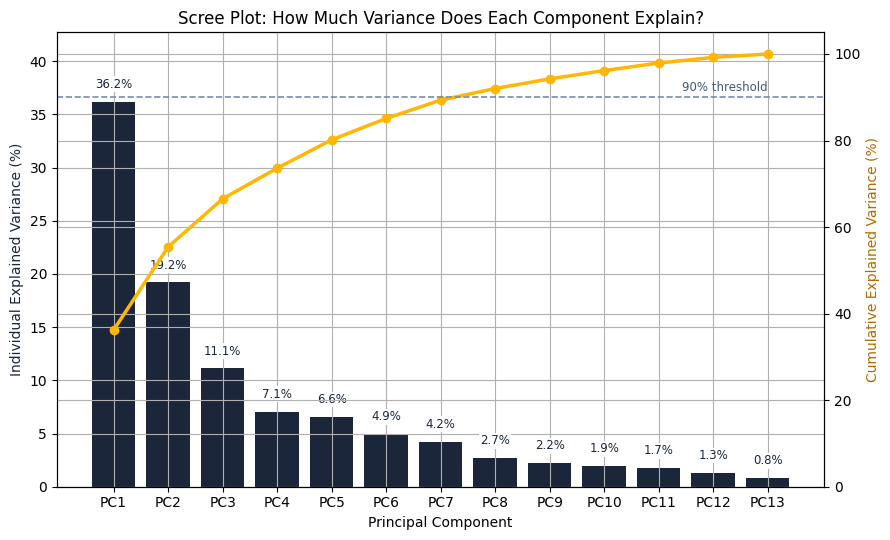

In [ ]:
n_components = len(explained_pct)
components_axis = np.arange(1, n_components + 1)

fig, ax1 = plt.subplots(figsize=(9, 5.5))

# Bars: how much variance THIS component adds.
bars = ax1.bar(components_axis, explained_pct, color="#1B263B", label="Individual % (per component)")
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Individual Explained Variance (%)", color="#1B263B")
ax1.set_xticks(components_axis)
ax1.set_xticklabels([f"PC{i}" for i in components_axis])
ax1.set_ylim(0, explained_pct.max() * 1.18)

# Label each bar with its exact percentage (white backing so the cumulative line never obscures it).
for bar, pct in zip(bars, explained_pct):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.3,
              f"{pct:.1f}%", ha="center", fontsize=8.5, color="#1B263B",
              bbox=dict(facecolor="white", edgecolor="none", pad=1.0), zorder=5)

# Line on a second y-axis: the RUNNING TOTAL so far.
ax2 = ax1.twinx()
ax2.plot(components_axis, cumulative_pct, color="#FFB703", marker="o", linewidth=2.5,
          label="Cumulative % (running total)")
ax2.set_ylabel("Cumulative Explained Variance (%)", color="#B36A00")
ax2.set_ylim(0, 105)
ax2.axhline(90, color="#778DA9", linestyle="--", linewidth=1.2)
ax2.text(n_components, 91.5, "90% threshold", ha="right", fontsize=8.5, color="#415A77")

plt.title("Scree Plot: How Much Variance Does Each Component Explain?")
fig.tight_layout()
plt.show()

Read it like this: the **bars shrink** as you go right — each additional component adds less new information
than the last (this is always true; PCA orders components from most- to least-important by construction).
The **gold line** shows you've crossed the 90% mark once it clears the dashed threshold — read straight down
to the x-axis to see how many components that took.

## 13. Seeing PCA actually work: 13 features → 2 components

Even though we need ~8 components to keep 90% of the information, just **2 components already capture ~55%**
— often enough to reveal real structure visually. Let's reduce the 13 standardized wine features down to 2
and plot them.

**PCA is unsupervised** — it is never shown `y_wine` (the cultivar labels). We'll use the labels **only to
color the plot afterward**, purely to check whether the structure PCA found on its own lines up with the real
cultivars.

In [ ]:
pca_2d = PCA(n_components=2)
X_wine_2d = pca_2d.fit_transform(X_wine_scaled)

print("Original shape:", X_wine_scaled.shape, " →  Reduced shape:", X_wine_2d.shape)
print("\nVariance kept by these 2 components:")
print(pd.DataFrame({
    "Component": ["PC1", "PC2"],
    "Explained_%": (pca_2d.explained_variance_ratio_ * 100).round(2),
    "Cumulative_%": (np.cumsum(pca_2d.explained_variance_ratio_) * 100).round(2),
}))

Original shape: (178, 13)  →  Reduced shape: (178, 2)

Variance kept by these 2 components:
  Component  Explained_%  Cumulative_%
0       PC1        36.20         36.20
1       PC2        19.21         55.41


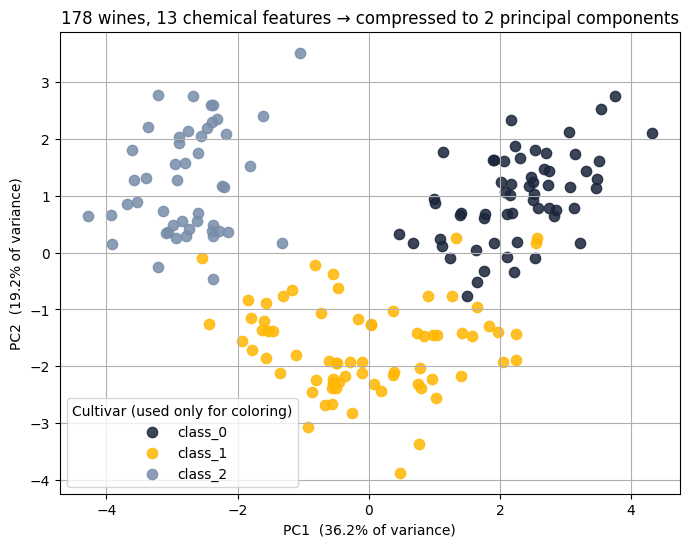

In [ ]:
plt.figure(figsize=(8, 6))

colors = ["#1B263B", "#FFB703", "#778DA9"]
for class_index, class_name in enumerate(wine.target_names):
    mask = y_wine == class_index
    plt.scatter(X_wine_2d[mask, 0], X_wine_2d[mask, 1],
                s=55, color=colors[class_index], label=class_name, alpha=0.85)

plt.xlabel(f"PC1  ({pca_2d.explained_variance_ratio_[0]*100:.1f}% of variance)")
plt.ylabel(f"PC2  ({pca_2d.explained_variance_ratio_[1]*100:.1f}% of variance)")
plt.title("178 wines, 13 chemical features → compressed to 2 principal components")
plt.legend(title="Cultivar (used only for coloring)")

plt.show()

Even though PCA never saw the cultivar labels, the three grape varieties largely separate into their own
regions once compressed down to just 2 numbers. That's the payoff: **13 numbers per wine → 2 numbers per
wine**, plottable on one chart, while still preserving enough structure to (roughly) tell the cultivars apart.

## 14. What is PC1 actually made of? (Reading the loadings)

Back in Section 2 we said a principal component is a **weighted combination of the original features**. Now
that we're on real data, let's actually read those weights — they're called **loadings**, and they live in
`pca.components_`.

## 15. What just happened?

We started with:

$$
13\ \text{features per wine}
$$

and ended with:

$$
2\ \text{principal components per wine}
$$

while keeping the directions that explain the largest amount of variance — and, as a bonus, those 2 numbers
turned out to roughly separate the 3 real cultivars, even though PCA was never told about them.

This is why PCA is useful for:

- dimensionality reduction
- visualization of high-dimensional data
- removing redundancy between correlated features
- preprocessing before some ML models
- speeding up training when there are many correlated features

But remember:

> **PCA does not know which features are useful for predicting any particular target.** It is an
> **unsupervised** technique — it only looks at variance, never at labels.

## 17. The complete PCA workflow

```text
                 ORIGINAL DATA
                       │
                       ▼
             Do scales differ a lot?
                  /          \
                YES           NO
                 │             │
                 ▼             │
          StandardScaler       │
                 │             │
                 └──────┬──────┘
                        ▼
                       PCA
                        │
                        ▼
             Find principal directions
                        │
              ┌─────────┴─────────┐
              ▼                   ▼
        Eigenvectors          Eigenvalues
          (directions)      (variance / importance)
              │                   │
              └─────────┬─────────┘
                        ▼
          Choose components (scree plot /
           cumulative explained variance)
                        │
                        ▼
                 Reduced data
```

## Six things to remember

1. **PCA reduces dimensions** — it re-expresses data using fewer, uncorrelated features.
2. **A principal component is a weighted combination of the original features.**
3. **Eigenvectors give the principal directions / weights** (`pca.components_`).
4. **Eigenvalues tell us how much variance each direction captures** (`pca.explained_variance_`).
5. **We standardize first** when features have very different scales/units — otherwise the
   largest-magnitude feature silently dominates every component.
6. **`explained_variance_ratio_` (and its cumulative sum) is how we decide how many components to keep** —
   the scree plot is the standard way to see that decision visually.